Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


Using device: cuda:3
Preparing MSW dataset (cv_pad=True)
Loaded cache with 7790 slices.
Finished MSW: 7790 slices.
Responders: 61 | Nonresponders: 5 | Unlabeled: 45
Preparing CHH dataset (cv_pad=True)
Generating consensus mean mask from 37 subjects...
Injecting 3 unlabeled subjects for pretraining...


Caching Volumes:   0%|          | 0/40 [00:00<?, ?it/s]

DEBUG: Showing orientation for Subject 13...


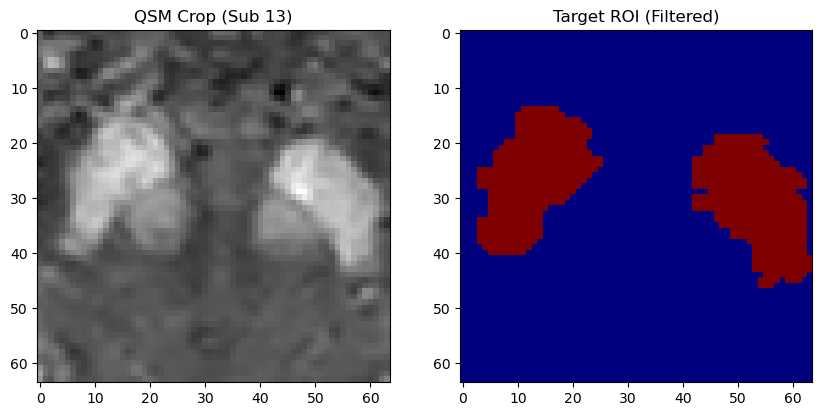

Caching Volumes: 100%|██████████| 40/40 [01:36<00:00,  2.40s/it]


Finished CHH: 2880 slices.
Responders: 34 | Nonresponders: 3 | Unlabeled: 3
Pretraining Minimal Spectral Attention + VAE...
Pretraining Mini Spatial Attention + VAE...
Pretraining Mini Spatial Attention + VAE...

Metric          | Ens Mani VAE    | Spectral ViT    | Spatial ViT    
-----------------------------------------------------------------
Accuracy        | 0.9215          | 0.8412          | 0.8386         
Sensitivity     | 0.9694          | 0.8566          | 0.9122         
Specificity     | 0.3796          | 0.6667          | 0.0046         
AUC             | 0.7890          | 0.7854          | 0.6911         
-----------------------------------------------------------------
Avg Threshold   | 0.0837          | 0.1089          | 0.1341         


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
from tqdm import tqdm
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
# Ensure these match your networks.py or define MinimalSpectralAttention here
from networks import SupervisedManifoldVAE 
from sklearn.preprocessing import StandardScaler
from util import seed_everything, get_m, RandomMasking, prepare_qsm_dataset
from util import mask_crop as mask_crop_fn
from sklearn.metrics import f1_score, balanced_accuracy_score
from train import get_mixed_data
import copy

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

EXP_NAME = "msw_to_chh_kfold_leak_free"
N_PCA_COMPONENTS = 128
AUG_FACTOR = 5 
NEG_OVERSAMPLE_FACTOR = 10 # 10 gave 0.6667
N_FOLDS = 5 # Standard 5-fold CV
seed_everything(0)

UNLABELED_CHH_PATH = "/media/mts_dbs/chh/nii/q" 

qsm_aug = transforms.Compose([
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.1))], p=0.5),
    RandomMasking(p=0.4)
])

# ============================================================
# 2. DATA LOADING & PRE-PROCESSING
# ============================================================
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', 
                                  '/media/mts_dbs/dbs/all/nii/seg_ps/',
                                  '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 
                                  'msw_cache_ax.pt', load_cache=True, mask_crop_fn=mask_crop_fn)

dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/',
                                   '/media/mts_dbs/chh/nii/roi/',
                                    '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv',
                                    'chh_cache_ax_f.pt', load_cache=False, mask_crop_fn=mask_crop_fn, 
                                    unlabeled_nii_path=UNLABELED_CHH_PATH)

def get_mixed_data(dataset, factor=1, aug=None):
    l_imgs, l_clins, l_lbls, u_imgs, u_clins = [], [], [], [], []
    for idx in range(len(dataset)):
        img, clin, lbl, _ = dataset[idx]
        img_np = img.squeeze().numpy().flatten()
        if lbl != -1:
            reps = NEG_OVERSAMPLE_FACTOR if lbl == 0 else 1
            for _ in range(reps):
                l_imgs.append(img_np); l_clins.append(clin.numpy()); l_lbls.append(lbl)
                if aug and factor > 1:
                    for _ in range(factor-1):
                        a_img = aug(img.clone()).squeeze().numpy().flatten()
                        l_imgs.append(a_img); l_clins.append(clin.numpy()); l_lbls.append(lbl)
        else:
            u_imgs.append(img_np); u_clins.append(clin.numpy())
    return np.array(l_imgs), np.array(l_clins), np.array(l_lbls), np.array(u_imgs), np.array(u_clins)

X_tr_img, X_tr_clin, y_tr, X_msw_un_img, _ = get_mixed_data(dataset_msw, AUG_FACTOR, qsm_aug)
num_clin = X_tr_clin.shape[1]
_, _, _, X_chh_un_img, X_chh_un_clin = get_mixed_data(dataset_chh)

# Domain Alignment (Scalers/PCA)
all_imgs = np.vstack([X_tr_img, X_msw_un_img, X_chh_un_img])
img_scaler = StandardScaler().fit(all_imgs)
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0).fit(img_scaler.transform(all_imgs))

def process_features(imgs, clins):
    return np.hstack([pca.transform(img_scaler.transform(imgs)), clins])

X_tr_proc = process_features(X_tr_img, X_tr_clin)
X_chh_un_proc = process_features(X_chh_un_img, X_chh_un_clin)

feat_scaler = StandardScaler().fit(np.vstack([X_tr_proc, X_chh_un_proc]))
X_tr_final = feat_scaler.transform(X_tr_proc)
X_chh_un_final = feat_scaler.transform(X_chh_un_proc)

# Prep Test Set
X_te_img_list, X_te_clin_list, y_te_list = [], [], []
for i in range(len(dataset_chh)):
    img, clin, lbl, _ = dataset_chh[i]
    if lbl != -1:
        img_np = img.numpy().squeeze()
        if img_np.ndim == 3: img_np = img_np[:, :, img_np.shape[2]//2]
        X_te_img_list.append(img_np.flatten()); X_te_clin_list.append(clin.numpy()); y_te_list.append(lbl)

X_test_final = feat_scaler.transform(process_features(np.array(X_te_img_list), np.array(X_te_clin_list)))
y_test = np.array(y_te_list)

# ============================================================
# Minimal Spectral Attention (Residual + Hierarchy)
# ============================================================
class MinimalSpectralAttention(nn.Module):
    def __init__(self, n_components, n_clinical, embed_dim=16, n_heads=4):
        super().__init__()
        self.n_components = n_components
        
        # Projections for both types of tokens
        self.input_projection = nn.Linear(1, embed_dim)
        self.clin_projection = nn.Linear(n_clinical, embed_dim) # New: Clinical Projector
        
        self.mha = nn.MultiheadAttention(embed_dim, n_heads)
        self.output_projection = nn.Linear(embed_dim, 1)
        
        indices = torch.arange(n_components).float()
        self.register_buffer('hierarchy_weight', torch.exp(-indices / 32).view(1, -1, 1))

    def forward(self, x):
        # 1. Split data
        pca_raw = x[:, :self.n_components].unsqueeze(-1) 
        clin_raw = x[:, self.n_components:]
        
        # 2. Project Spectral Tokens
        h_spec = self.input_projection(pca_raw * self.hierarchy_weight) # (B, N_PCA, Dim)
        
        # 3. Project Clinical Data into a single "Global Context Token"
        h_clin = self.clin_projection(clin_raw).unsqueeze(1) # (B, 1, Dim)
        
        # 4. Concatenate: Now the sequence is [Spectral_1, ..., Spectral_N, Clinical_Token]
        combined_tokens = torch.cat([h_spec, h_clin], dim=1)
        
        # 5. Multi-Head Attention (Self-Attention across all tokens)
        h = combined_tokens.transpose(0, 1) 
        attn_out, _ = self.mha(h, h, h)
        h_out = attn_out.transpose(0, 1)
        
        # 6. Extract the Spectral part back out and project back to raw PCA space
        spectral_context = self.output_projection(h_out[:, :self.n_components, :])
        pca_out = (pca_raw + 0.1 * spectral_context).squeeze(-1) 
        
        # We return the original clinical features + the refined PCA
        return torch.cat([pca_out, clin_raw], dim=1)
# ============================================================
# NEW: Mini Spatial Attention (Bottlenecked for Efficiency)
# ============================================================
class MiniSpatialAttention(nn.Module):
    def __init__(self, img_dim=64, patch_size=16, n_clinical=5, embed_dim=16, n_heads=4, target_dim=128):
        super().__init__()
        self.img_dim = img_dim
        self.patch_size = patch_size
        self.n_patches = (img_dim // patch_size) ** 2 
        
        # Projections
        self.patch_projection = nn.Linear(patch_size**2, embed_dim)
        self.clin_projection = nn.Linear(n_clinical, embed_dim) # Clinical -> Embedding
        
        # Spatial Awareness
        self.pos_embedding = nn.Parameter(torch.randn(1, self.n_patches + 1, embed_dim)) # +1 for clinical token
        self.mha = nn.MultiheadAttention(embed_dim, n_heads)
        
        # Bottleneck to keep VAE input consistent (128 + n_clinical)
        self.bottleneck = nn.Linear(self.n_patches * embed_dim, target_dim)

    def forward(self, x):
        # 1. Unpack Raw Pixels and Clinical Data
        x_img_raw = x[:, :self.img_dim**2]
        x_clin = x[:, self.img_dim**2:]
        B = x_img_raw.shape[0]
        
        # 2. Tokenize Image Patches
        x_img = x_img_raw.view(B, 1, self.img_dim, self.img_dim)
        patches = x_img.unfold(2, self.patch_size, self.patch_size)\
                       .unfold(3, self.patch_size, self.patch_size)\
                       .contiguous().view(B, self.n_patches, -1)
        h_patches = self.patch_projection(patches) # (B, n_patches, embed_dim)
        
        # 3. Project Clinical Context Token
        h_clin = self.clin_projection(x_clin).unsqueeze(1) # (B, 1, embed_dim)
        
        # 4. Concatenate: [Clinical Token, Patch 1, ..., Patch N]
        # Adding position embeddings to everything
        combined = torch.cat([h_clin, h_patches], dim=1) + self.pos_embedding
        
        # 5. Multi-Head Attention
        # Now every patch "sees" the clinical data during the attention sweep
        h = combined.transpose(0, 1)
        attn_out, _ = self.mha(h, h, h)
        h_out = attn_out.transpose(0, 1)
        
        # 6. Separate and Refine
        # We extract the patches back out to go through the bottleneck
        spatial_refined = h_out[:, 1:, :].reshape(B, -1)
        spatial_compressed = self.bottleneck(spatial_refined)
        
        # Return compressed spatial features + original clinical features for the VAE
        return torch.cat([spatial_compressed, x_clin], dim=1)
# ============================================================
# 3. TRAINING REDUCED MODELS
# ============================================================
def calibrate_balanced(model, attn, X_v, y_v):
    model.eval()
    if attn: attn.eval()
    with torch.no_grad():
        x_t = torch.tensor(X_v, dtype=torch.float32).to(device)
        p = model(attn(x_t) if attn else x_t, mode='fine_tune').cpu().numpy()
    
    best_t, best_bal = 0.5, 0
    for t in np.linspace(0.01, 0.9, 100):
        score = balanced_accuracy_score(y_v, (p >= t))
        if score > best_bal:
            best_bal, best_t = score, t
    return best_t

# Models - Note: base_vs now uses 128 + num_clin due to bottleneck
base_v = SupervisedManifoldVAE(X_tr_final.shape[1]).to(device)
base_va = SupervisedManifoldVAE(X_tr_final.shape[1]).to(device)
base_attn = MinimalSpectralAttention(N_PCA_COMPONENTS,n_clinical=num_clin).to(device)

# Updated Spatial Baseline with Bottleneck
base_vs = SupervisedManifoldVAE(128 + num_clin).to(device)
base_at_spatial = MiniSpatialAttention(img_dim=64,n_clinical=num_clin).to(device)

X_pre = torch.tensor(np.vstack([X_tr_final, X_chh_un_final]), dtype=torch.float32).to(device)
pre_loader = DataLoader(TensorDataset(X_pre), batch_size=128, shuffle=True)
mse = nn.MSELoss()

# Pretrain VAE only
opt_v = optim.Adam(base_v.parameters(), lr=1e-3)
for _ in range(30):
    for b in pre_loader:
        clean = b[0]
        opt_v.zero_grad()
        rec, mu1, logv1 = base_v(clean + torch.randn_like(clean)*0.05, mode='pretrain')
        loss = mse(rec, clean) + 0.01*(-0.5*torch.sum(1+logv1-mu1.pow(2)-logv1.exp())/clean.size(0))
        loss.backward(); opt_v.step()

# Joint pretraining for Minimal Spectral ViT
print("Pretraining Minimal Spectral Attention + VAE...")
opt_va = optim.Adam(list(base_va.parameters()) + list(base_attn.parameters()), lr=1e-3)
for _ in range(30):
    for b in pre_loader:
        clean = b[0]
        opt_va.zero_grad()
        v1 = base_attn(clean + torch.randn_like(clean)*0.05)
        rec, mu, logv = base_va(v1, mode='pretrain')
        loss = mse(rec, clean) + 0.01*(-0.5*torch.sum(1+logv-mu.pow(2)-logv.exp())/clean.size(0))
        loss.backward(); opt_va.step()

# Spatial unified vectors
X_tr_spatial_final = np.hstack([X_tr_img, X_tr_clin])
X_chh_un_spatial = np.hstack([X_chh_un_img, X_chh_un_clin])
X_test_spatial_final = np.hstack([np.array(X_te_img_list), np.array(X_te_clin_list)])

X_pre_spatial = torch.tensor(np.vstack([X_tr_spatial_final, X_chh_un_spatial]), dtype=torch.float32).to(device)
pre_loader_raw = DataLoader(TensorDataset(X_pre_spatial), batch_size=128, shuffle=True)

print("Pretraining Mini Spatial Attention + VAE...")
print("Pretraining Mini Spatial Attention + VAE...")
opt_vs = optim.Adam(list(base_vs.parameters()) + list(base_at_spatial.parameters()), lr=1e-3)

for _ in range(30):
    for b in pre_loader_raw:
        clean_raw = b[0]
        opt_vs.zero_grad()
        
        # 1. Compress raw pixels to latent tokens (137 dims)
        v_spatial = base_at_spatial(clean_raw + torch.randn_like(clean_raw)*0.05)
        
        # 2. VAE reconstructs the 137-dim latent space, NOT the 4105-dim pixels
        rec, mu, logv = base_vs(v_spatial, mode='pretrain')
        
        # 3. Target is now v_spatial (the compressed version)
        loss = mse(rec, v_spatial.detach()) + 0.01*(-0.5*torch.sum(1+logv-mu.pow(2)-logv.exp())/v_spatial.size(0))
        
        loss.backward()
        opt_vs.step()

# K-Fold Loop
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
fold_preds_v, fold_preds_va, fold_preds_vs = [], [], []
fold_ths_v, fold_ths_va, fold_ths_vs = [], [], []

NEG_WEIGHT = 12

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr_final, y_tr)):
    X_f_train_pca, X_f_val_pca = X_tr_final[train_idx], X_tr_final[val_idx]
    X_f_train_spatial, X_f_val_spatial = X_tr_spatial_final[train_idx], X_tr_spatial_final[val_idx]
    y_f_train, y_f_val = y_tr[train_idx], y_tr[val_idx]

    m_v, m_va, m_at = copy.deepcopy(base_v), copy.deepcopy(base_va), copy.deepcopy(base_attn)
    m_vs, m_ats = copy.deepcopy(base_vs), copy.deepcopy(base_at_spatial)

    ft_loader = DataLoader(TensorDataset(
        torch.tensor(X_f_train_pca, dtype=torch.float32).to(device),
        torch.tensor(X_f_train_spatial, dtype=torch.float32).to(device),
        torch.tensor(y_f_train, dtype=torch.float32).to(device)
    ), batch_size=64, shuffle=True)

    opt_v = optim.Adam(m_v.parameters(), lr=1e-5, weight_decay=1e-2)
    opt_va = optim.Adam([{'params': m_va.parameters(), 'lr': 2e-5}, {'params': m_at.parameters(), 'lr': 8e-5}], weight_decay=5e-2)
    opt_vs = optim.Adam([{'params': m_vs.parameters(), 'lr': 2e-5}, {'params': m_ats.parameters(), 'lr': 8e-5}], weight_decay=5e-2)

    for _ in range(50):
        for b_pca, b_spatial, by in ft_loader:
            smoothed_labels = by * 0.95 + (1 - by) * 0.05
            weights = (by == 0).float() * NEG_WEIGHT + 1.0
            
            opt_v.zero_grad()
            loss_v = nn.functional.binary_cross_entropy(m_v(b_pca, mode='fine_tune'), smoothed_labels, weight=weights)
            loss_v.backward(); opt_v.step()

            opt_va.zero_grad()
            loss_va = nn.functional.binary_cross_entropy(m_va(m_at(b_pca), mode='fine_tune'), smoothed_labels, weight=weights)
            loss_va.backward(); opt_va.step()

            opt_vs.zero_grad()
            loss_vs = nn.functional.binary_cross_entropy(m_vs(m_ats(b_spatial), mode='fine_tune'), smoothed_labels, weight=weights)
            loss_vs.backward(); opt_vs.step()

    fold_ths_v.append(calibrate_balanced(m_v, None, X_f_val_pca, y_f_val))
    fold_ths_va.append(calibrate_balanced(m_va, m_at, X_f_val_pca, y_f_val))
    fold_ths_vs.append(calibrate_balanced(m_vs, m_ats, X_f_val_spatial, y_f_val))
    
    with torch.no_grad():
        t_te_pca = torch.tensor(X_test_final, dtype=torch.float32).to(device)
        t_te_spatial = torch.tensor(X_test_spatial_final, dtype=torch.float32).to(device)
        
        fold_preds_v.append(m_v(t_te_pca, mode='fine_tune').cpu().numpy())
        fold_preds_va.append(m_va(m_at(t_te_pca), mode='fine_tune').cpu().numpy())
        fold_preds_vs.append(m_vs(m_ats(t_te_spatial), mode='fine_tune').cpu().numpy())
        
pv, pva, pvs = np.mean(fold_preds_v, axis=0), np.mean(fold_preds_va, axis=0), np.mean(fold_preds_vs, axis=0)
th_v, th_va, th_vs = np.mean(fold_ths_v), np.mean(fold_ths_va), np.mean(fold_ths_vs)

res = [get_m(y_test, (pv >= th_v), pv), get_m(y_test, (pva >= th_va), pva), get_m(y_test, (pvs >= th_vs), pvs)]
names = ['Ens Mani VAE', 'Spectral ViT', 'Spatial ViT']

print(f"\n{'Metric':<15} | " + " | ".join([f"{n:<15}" for n in names]))
print("-" * 65)
for i, m_name in enumerate(['Accuracy', 'Sensitivity', 'Specificity', 'AUC']):
    row_values = " | ".join([f"{r[i]:<15.4f}" for r in res])
    print(f"{m_name:<15} | {row_values}")
print("-" * 65)
print(f"{'Avg Threshold':<15} | {th_v:<15.4f} | {th_va:<15.4f} | {th_vs:<15.4f}")

In [2]:
balanced_acc = [(r[1] + r[2]) / 2 for r in res]

print(f"\n{'Metric':<15} | " + " | ".join([f"{n:<15}" for n in names]))
print("-" * 80)

metric_names = ['Accuracy', 'Sensitivity', 'Specificity']

for i, m_name in enumerate(metric_names):
    row_values = " | ".join([f"{r[i]:<15.4f}" for r in res])
    print(f"{m_name:<15} | {row_values}")

# balanced accuracy row
row_values = " | ".join([f"{b:<15.4f}" for b in balanced_acc])
print(f"{'Balanced Acc':<15} | {row_values}")

# AUC row (still index 3)
row_values = " | ".join([f"{r[3]:<15.4f}" for r in res])
print(f"{'AUC':<15} | {row_values}")

print("-" * 80)
print(f"{'Avg Threshold':<15} | {th_v:<15.4f} | {th_va:<15.4f} | {th_vs:<15.4f}")


Metric          | Ens Mani VAE    | Spectral ViT    | Spatial ViT    
--------------------------------------------------------------------------------
Accuracy        | 0.9215          | 0.8412          | 0.8386         
Sensitivity     | 0.9694          | 0.8566          | 0.9122         
Specificity     | 0.3796          | 0.6667          | 0.0046         
Balanced Acc    | 0.6745          | 0.7616          | 0.4584         
AUC             | 0.7890          | 0.7854          | 0.6911         
--------------------------------------------------------------------------------
Avg Threshold   | 0.0837          | 0.1089          | 0.1341         
